#### Импортирование библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
events_df = pd.read_csv('events.csv')
events_df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [3]:
events_df.describe()

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


In [4]:
all_customers = events_df.visitorid.unique()
print(all_customers.size)

1407580


In [5]:
customer_purchased = events_df[events_df.transactionid.notnull()].visitorid.unique()
print(customer_purchased.size)

11719


In [6]:
events_df[events_df.visitorid == 102019].sort_values('timestamp')

,timestamp,visitorid,event,itemid,transactionid
19690,1433175714335,102019,view,49521,NaN
19501,1433175801314,102019,addtocart,49521,NaN
14842,1433175812596,102019,view,150318,NaN
19573,1433175871497,102019,view,49521,NaN
8701,1433175894837,102019,view,49521,NaN
19708,1433175945872,102019,view,150318,NaN
8740,1433176042269,102019,view,49521,NaN
814,1433176736375,102019,transaction,150318,13556.0
19724,1433176736422,102019,transaction,49521,13556.0


In [7]:
events_df['event'].unique()

array(['view', 'addtocart', 'transaction'], dtype=object)

In [8]:
events_count = events_df['event'].value_counts()
events_count

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

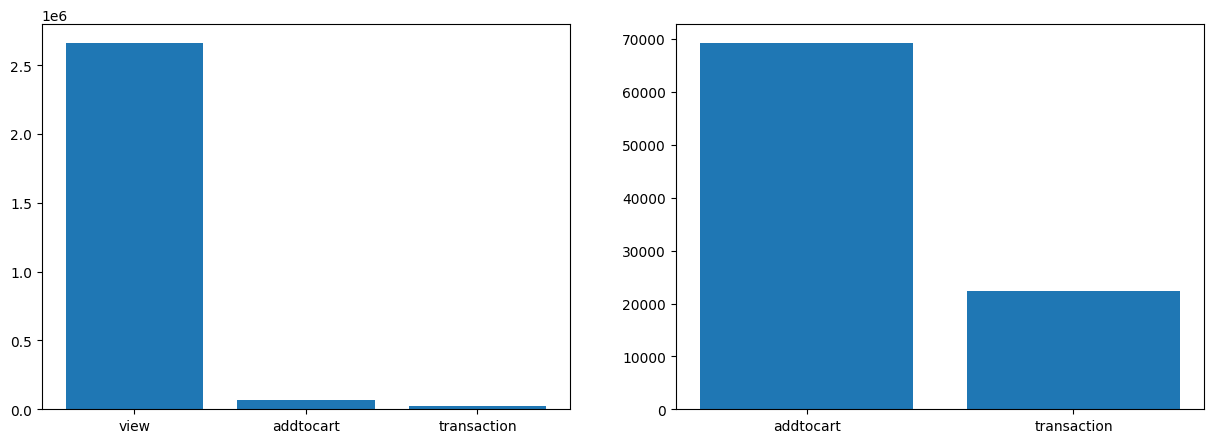

In [9]:
plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.bar(events_count.index, events_count.values)

plt.subplot(1,2,2)
plt.bar(events_count.index[1:], events_count.values[1:])

plt.show()

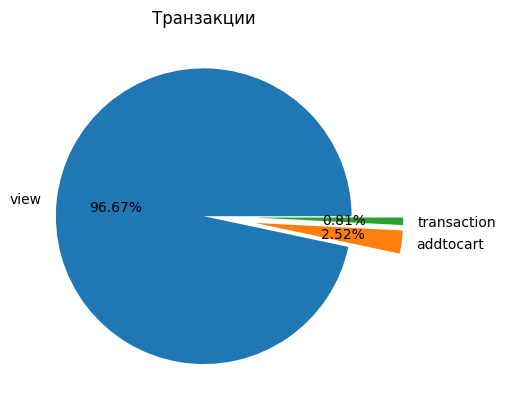

In [10]:
plt.title('Транзакции')
explode = (0, 0.35, 0.35)
plt.pie(events_count.values, explode=explode, labels=events_count.index, autopct="%1.2f%%")
plt.show()

In [11]:
grouped = events_df.groupby('event')['itemid'].apply(np.array)
grouped

event
addtocart      [5206, 10572, 255275, 356475, 312728, 63312, 1...
transaction    [356475, 15335, 81345, 150318, 310791, 54058, ...
view           [355908, 248676, 318965, 253185, 367447, 22556...
Name: itemid, dtype: object

#### Наиболее частые просмотры

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_71011/3950373098.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, order=x, palette='rocket')


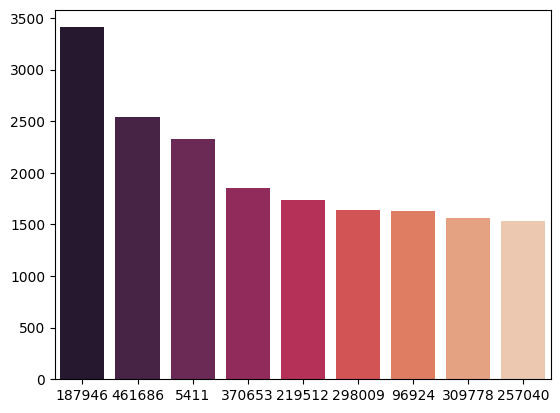

In [13]:
import operator
views = grouped['view']
count_view = {}
views = np.array(views[:])
unique, counts = np.unique(views, return_counts=True)
count_view = dict(zip(unique, counts))
sort_count_view = sorted(count_view.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_view[:9]]
y = [i[1] for i in sort_count_view[:9]]
sns.barplot(x=x, y=y, order=x, palette='rocket')
plt.show()

#### Наиболее частые добавления в корзину

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_71011/1694845266.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, order=x, palette='pastel')


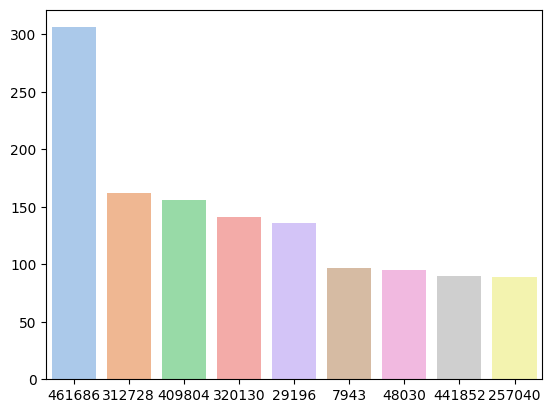

In [14]:
addtocart = grouped['addtocart']
count_addtocart = {}
addtocart = np.array(addtocart[:])
unique, counts = np.unique(addtocart, return_counts=True)
count_addtocart = dict(zip(unique, counts))
sort_count_addtocart = sorted(count_addtocart.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_addtocart[:9]]
y = [i[1] for i in sort_count_addtocart[:9]]
sns.barplot(x=x, y=y, order=x, palette='pastel')
plt.show()

#### Наиболее частые покупки

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_71011/193942944.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, order=x, palette='pastel')


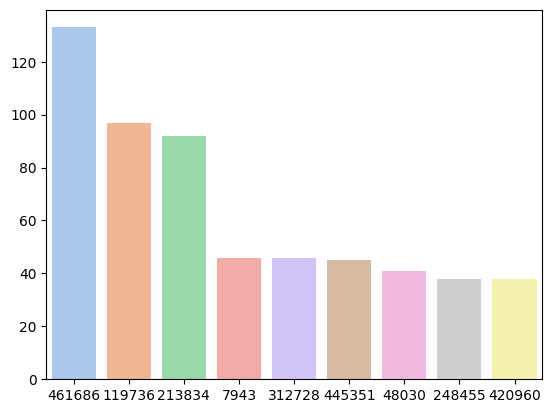

In [15]:
transaction = grouped['transaction']
count_transaction = {}
transaction = np.array(transaction[:])
unique, counts = np.unique(transaction, return_counts=True)
count_transaction = dict(zip(unique, counts))
sort_count_transaction = sorted(count_transaction.items(), key=operator.itemgetter(1), reverse=True)
x = [i[0] for i in sort_count_transaction[:9]]
y = [i[1] for i in sort_count_transaction[:9]]
sns.barplot(x=x, y=y, order=x, palette='pastel')
plt.show()

#### Построение рекомендации

In [19]:
purchased_items = []

for customer in customer_purchased:
    purchased_items.append(list(events_df.loc[(events_df.visitorid == customer) & (events_df.transactionid.notnull())].itemid.values))

In [20]:
purchased_items[:5]

[[356475],
 [15335,
  380775,
  237753,
  317178,
  12836,
  400969,
  105792,
  25353,
  200793,
  80582,
  302422],
 [81345],
 [150318, 49521],
 [310791, 299044]]

In [24]:
def recommend_items(item_id, purchased_items):
    recommendation_list = []
    for x in purchased_items:
        if item_id in x:
            recommendation_list += x
    recommendation_list = list(set(recommendation_list) - set([item_id]))
    return recommendation_list

In [25]:
recommend_items(200793, purchased_items)

[105792, 12836, 80582, 380775, 15335, 400969, 25353, 302422, 237753, 317178]

In [26]:
recommend_items(317178, purchased_items)

[105792, 200793, 12836, 80582, 380775, 15335, 400969, 25353, 302422, 237753]